In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from pathlib import Path

Load processed data

In [4]:
PROJECT_ROOT = Path.cwd().parent

PRICE_FILE = PROJECT_ROOT / "data" / "processed" / "prices.csv"
RETURNS_FILE = PROJECT_ROOT / "data" / "processed" / "returns.csv"

prices = pd.read_csv(PRICE_FILE)
returns = pd.read_csv(RETURNS_FILE)

prices["date"] = pd.to_datetime(prices["date"])
returns["date"] = pd.to_datetime(returns["date"])

print(prices.head())
print(returns.head())

        date    HDFCBANK   ICICIBANK         INFY         ITC           LT  \
0 2024-01-01  812.994568  983.282715  1429.635986  401.752533  3432.108643   
1 2024-01-02  813.473328  966.409302  1414.015869  403.726776  3347.071533   
2 2024-01-03  800.929626  968.180237  1373.099243  409.649414  3349.261963   
3 2024-01-04  809.523499  971.230286  1394.018433  408.919800  3367.126221   
4 2024-01-05  805.382202  977.674622  1412.311035  406.816833  3428.652832   

      RELIANCE        SBIN          TCS  
0  1279.692871  607.407227  3482.784912  
1  1290.290039  605.607910  3457.288330  
2  1276.259399  609.396179  3373.716553  
3  1282.854614  608.733154  3350.916016  
4  1288.313843  607.975525  3415.890381  
        date  HDFCBANK  ICICIBANK      INFY       ITC        LT  RELIANCE  \
0 2024-01-02  0.000589  -0.017160 -0.010926  0.004914 -0.024777  0.008281   
1 2024-01-03 -0.015420   0.001832 -0.028936  0.014670  0.000654 -0.010874   
2 2024-01-04  0.010730   0.003150  0.015235 -0.0

Dataset Overview

In [5]:
print("Price Matrix Shape :", prices.shape)
print("Returns Matrix Shape :", returns.shape)

print("\nColumns:\n")
print(prices.columns)

print("\nData Types:\n")
print(prices.dtypes)

Price Matrix Shape : (638, 9)
Returns Matrix Shape : (637, 9)

Columns:

Index(['date', 'HDFCBANK', 'ICICIBANK', 'INFY', 'ITC', 'LT', 'RELIANCE',
       'SBIN', 'TCS'],
      dtype='str')

Data Types:

date         datetime64[us]
HDFCBANK            float64
ICICIBANK           float64
INFY                float64
ITC                 float64
LT                  float64
RELIANCE            float64
SBIN                float64
TCS                 float64
dtype: object


Missing Values

In [6]:
print(prices.isnull().sum())

print()

print(returns.isnull().sum())

date         0
HDFCBANK     0
ICICIBANK    0
INFY         0
ITC          0
LT           0
RELIANCE     0
SBIN         0
TCS          0
dtype: int64

date         0
HDFCBANK     0
ICICIBANK    0
INFY         0
ITC          0
LT           0
RELIANCE     0
SBIN         0
TCS          0
dtype: int64


Summary Statistics

In [7]:
prices.describe()

,date,HDFCBANK,ICICIBANK,INFY,ITC,LT,RELIANCE,SBIN,TCS
count,638,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000
mean,2025-04-16 16:21:49.090909,844.518442,1276.333940,1496.208238,376.028917,3625.188082,1386.572672,839.591245,3277.525845
min,2024-01-01 00:00:00,662.637756,963.949585,985.299988,275.549988,2996.659668,1151.951782,573.075745,1971.788818
25%,2024-08-27 06:00:00,779.857666,1208.797913,1364.989777,357.252319,3457.705139,1313.681213,755.513031,2935.655518
50%,2025-04-19 00:00:00,829.591614,1288.058044,1498.309631,385.403168,3572.061279,1399.870117,797.622772,3317.917480
75%,2025-12-07 06:00:00,935.121445,1389.399994,1637.749023,403.603493,3832.275940,1453.812164,950.853348,3761.375244
max,2026-07-28 00:00:00,996.419800,1477.201782,1901.082886,463.949249,4375.364258,1584.971802,1206.060669,4230.709473
std,NaN,93.260187,130.071300,211.496610,47.632694,268.315581,95.294946,131.593682,571.991687


Price Comparison

In [8]:
fig = px.line(
    prices,
    x="date",
    y=prices.columns[1:],
    title="Stock Price Comparison",
    labels={
        "value": "Closing Price (₹)",
        "date": "Date",
        "variable": "Stock"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

Normalized Price Comparison

In [9]:
normalized = prices.copy()

for col in normalized.columns[1:]:
    normalized[col] = normalized[col] / normalized[col].iloc[0] * 100

fig = px.line(
    normalized,
    x="date",
    y=normalized.columns[1:],
    title="Normalized Stock Performance (Base = 100)",
    labels={
        "value": "Normalized Price",
        "date": "Date",
        "variable": "Stock"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

Daily Returns Comparison

In [10]:
fig = px.line(
    returns,
    x="date",
    y=returns.columns[1:],
    title="Daily Returns of Stocks",
    labels={
        "value": "Daily Return",
        "date": "Date",
        "variable": "Stock"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

Correlation Heatmap

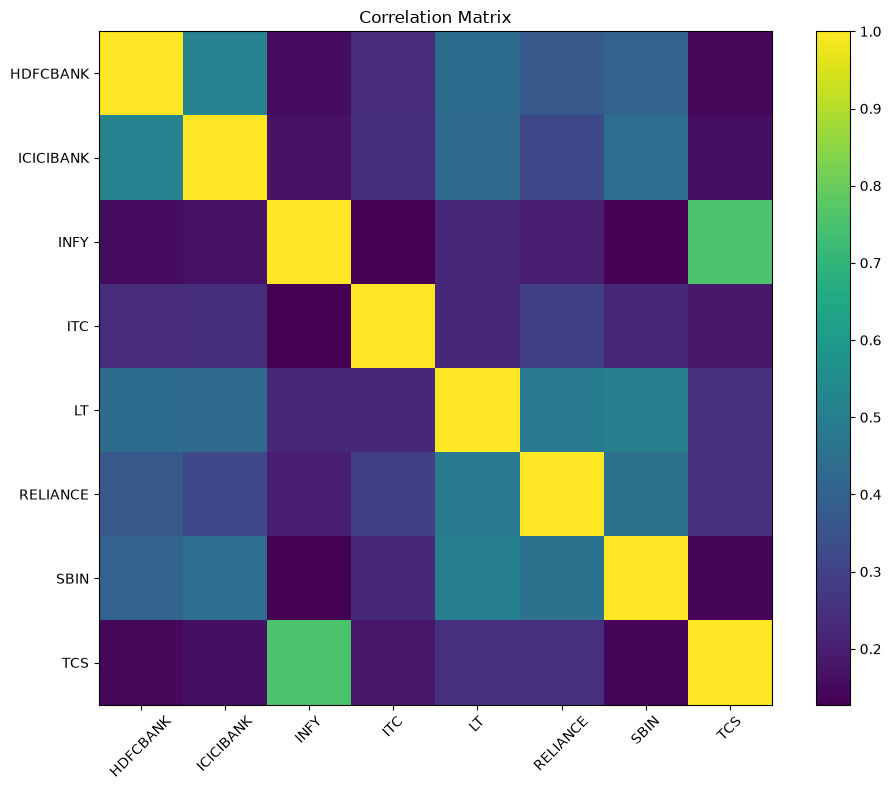

In [11]:
correlation = returns.iloc[:, 1:].corr()

plt.figure(figsize=(10, 8))

plt.imshow(correlation, interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

Rolling 30-Day Volatility

In [12]:
rolling_volatility = (
    returns
    .iloc[:, 1:]
    .rolling(window=30)
    .std()
)

rolling_volatility["date"] = returns["date"]

fig = px.line(
    rolling_volatility,
    x="date",
    y=rolling_volatility.columns[:-1],
    title="30-Day Rolling Volatility",
    labels={
        "value": "Volatility",
        "date": "Date",
        "variable": "Stock"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()